https://de.wikipedia.org/wiki/Canny-Algorithmus

In [1]:
import numpy as np
import matplotlib.pyplot as pl
import cv2 as cv

In [2]:
img = cv.imread ('canny-input.jpeg')

In [3]:
img = cv.cvtColor (img, cv.COLOR_BGR2GRAY)

In [4]:
img = img / 255.0

In [5]:
def Show (img):
    pl.imshow (img, cmap = 'gray')
    pl.axis ('off')

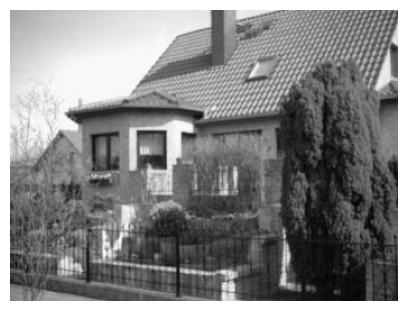

In [6]:
pl.figure (figsize = (5, 5))
Show (img)

In [7]:
r = 5
img = cv.GaussianBlur (img, (r, r) ,0)

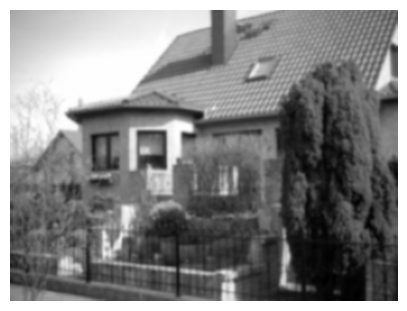

In [8]:
pl.figure (figsize = (5, 5))
Show (img)

In [9]:
SobelX = np.array ([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

In [10]:
sx = cv.filter2D (img, -1, SobelX)

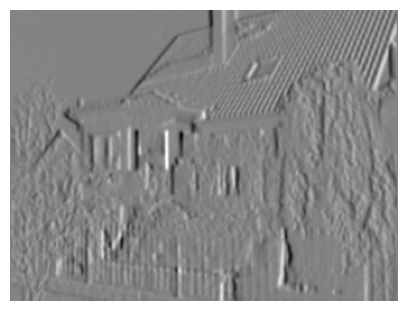

In [11]:
pl.figure (figsize = (5, 5))
Show (sx)

In [12]:
SobelY = np.array ([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

In [13]:
sy = cv.filter2D (img, -1, SobelY)

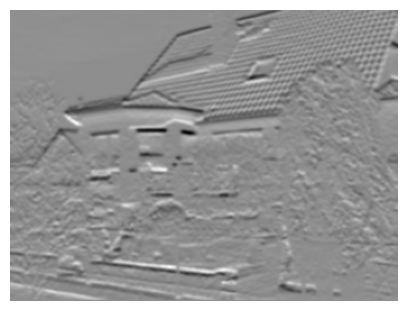

In [14]:
pl.figure (figsize = (5, 5))
Show (sy)

In [15]:
s1 = np.sqrt (sx ** 2 + sy ** 2)

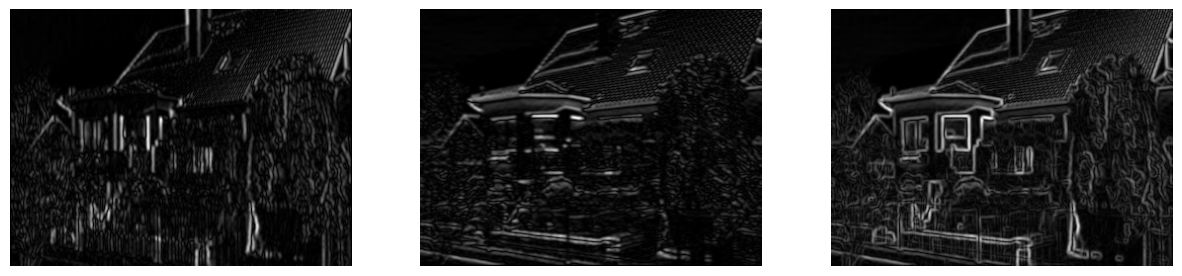

In [16]:
pl.figure (figsize = (15, 5))
pl.subplot (1, 3, 1); Show (np.abs (sx))
pl.subplot (1, 3, 2); Show (np.abs (sy))
pl.subplot (1, 3, 3); Show (np.abs (s1))

In [17]:
s2 = np.maximum (np.abs (sx), np.abs (sy))

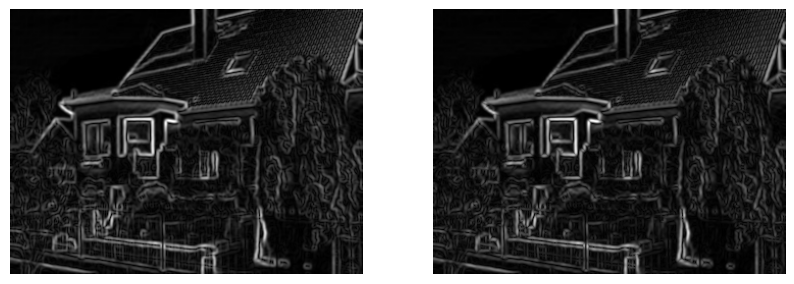

In [18]:
pl.figure (figsize = (10, 5))
pl.subplot (1, 2, 1); Show (np.abs (s1))
pl.subplot (1, 2, 2); Show (np.abs (s2))

In [19]:
def DirImg (x, y):
    phi = np.arctan2 (sy, sx)
    dir = np.round (4 * (phi / np.pi + 1))
    dir [dir == 8] = 0
    dir [dir >= 4] -= 4
    return dir

In [20]:
dirimg = DirImg (sx, sy)

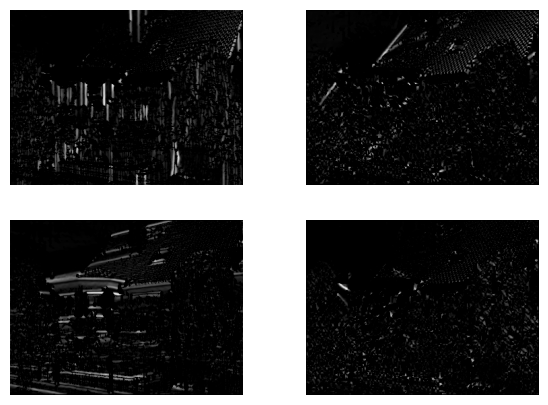

In [21]:
pl.figure (figsize = (7, 5))
pl.subplot (2, 2, 1); Show ((dirimg == 0) * s1)
pl.subplot (2, 2, 2); Show ((dirimg == 1) * s1)
pl.subplot (2, 2, 3); Show ((dirimg == 2) * s1)
pl.subplot (2, 2, 4); Show ((dirimg == 3) * s1)

In [22]:
def Cancel (dir, u, v, dirimg, img):
    m, n = img.shape
    res = np.zeros ((m, n))
    for i in range (1, m - 1):
        for k in range (1, n - 1):
            pix = img [i, k]
            res [i, k] = pix
            if dir == dirimg [i, k]:
                if img [i + u, k + v] > pix or img [i - u, k - v] > pix:
                    res [i, k] = 0
    return res;

In [23]:
res0 = Cancel (0, 0, 1, dirimg, s1)

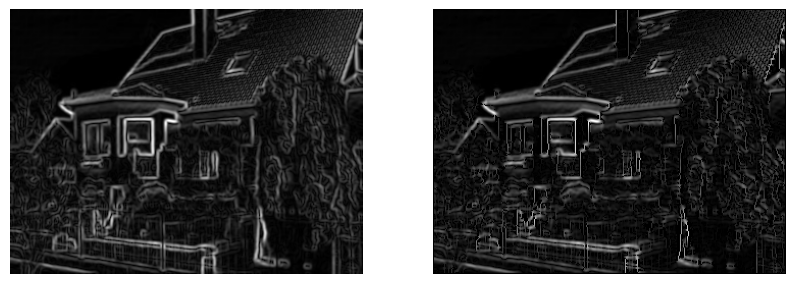

In [24]:
pl.figure (figsize = (10, 5))
pl.subplot (1, 2, 1); Show (s1)
pl.subplot (1, 2, 2); Show (res0)

In [25]:
res1 = Cancel (1, 1, 1, dirimg, res0)

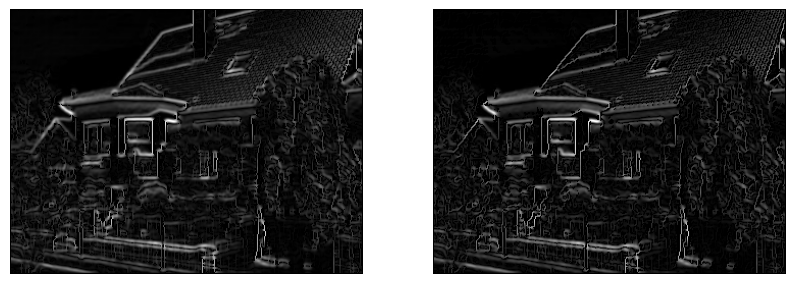

In [26]:
pl.figure (figsize = (10, 5))
pl.subplot (1, 2, 1); Show (res0)
pl.subplot (1, 2, 2); Show (res1)

In [27]:
res2 = Cancel (2, 1, 0, dirimg, res1)

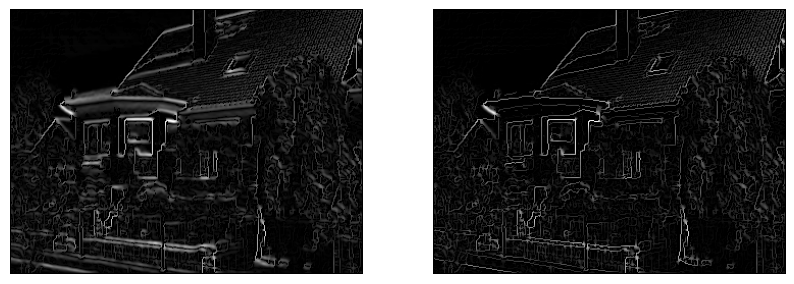

In [28]:
pl.figure (figsize = (10, 5))
pl.subplot (1, 2, 1); Show (res1)
pl.subplot (1, 2, 2); Show (res2)

In [29]:
res3 = Cancel (3, 1, -1, dirimg, res2)

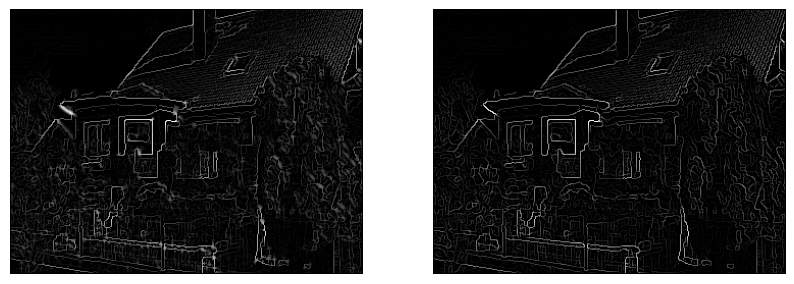

In [30]:
pl.figure (figsize = (10, 5))
pl.subplot (1, 2, 1); Show (res2)
pl.subplot (1, 2, 2); Show (res3)

In [31]:
print (np.min (res3), np.max (res3))

0.0 1.84824699400025


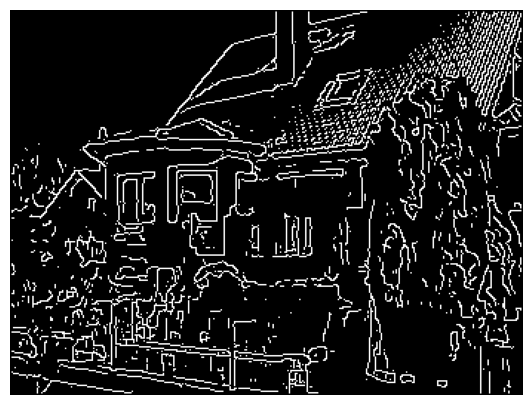

In [32]:
pl.figure (figsize = (10, 5))
Show (res3 > 0.3)